# Churn Analysis & Customer Intelligence

An end-to-end analysis of a subscription business's churn — **why** customers cancel and **what it costs**. Starting from a SQLite database of customer, subscription, and support tables, the notebook walks through SQL→pandas ingestion, data cleaning, feature engineering, and 14 churn and revenue KPIs, surfacing the segments and behaviors most linked to churn so retention effort can be prioritized. *Stack: Python (pandas, NumPy), SQLite, matplotlib, seaborn.*

## 1. Setup & Data Import

Connects to the SQLite database, lists its tables, and loads each one (customer, subscription, support) into its own pandas DataFrame, ready for cleaning.

In [1]:
# importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

In [2]:
# Connecting to the SQLite database and list its tables
conn = sqlite3.connect('../data/raw/customer_churn.db')

query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(query, conn)
tables

,name
0,db_customer
1,db_subscription
2,db_support


In [3]:
# Loading each table into a separate DataFrame (df_db_customer, etc.)
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


## 2. Data Cleaning

Prepares each table for analysis: fixes data types (dates stored as text), renames and drops columns, normalizes inconsistent categories (gender, acquisition channel), and fills missing values using logic derived from the data itself rather than dropping rows.

In [4]:
# Inspecting each table's schema directly via SQL (PRAGMA)
conn = sqlite3.connect('../data/raw/customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable: {table_name}")
    columns = pd.read_sql(f"PRAGMA table_info({table_name});", conn)
    print(columns['name'].tolist())

conn.close()


Table: db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table: db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table: db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
# Detailed look at customer table: types and missing values
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [6]:
# Inspecting top 5 rows to understand the data
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:
# Inspecting bottom 5 rows to understand the data
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


### Cleaning tasks — customer table
1. Rename `name` → `customer_name`
2. Drop `interests` and `pincode` (mostly/entirely empty)
3. Convert `dob` from text to datetime
4. Standardize `gender` (Men→Male, Women→Female)
5. Fill missing `country` values using a state→country map

In [8]:
# 1. Rename 'name' to 'customer_name' for clarity
df_db_customer = df_db_customer.rename(columns = {'name': 'customer_name'})
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
# 2. Dropping columns that are empty or not useful for analysis
df_db_customer = df_db_customer.drop(columns = ['interests', 'pincode'])
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [10]:
# 3. Converting 'dob' from text to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [11]:
# Checking what gender values actually exist
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [12]:
# 4. Standardizing gender values to Male / Female
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [13]:
# Which rows have a missing country?
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [14]:
# 5. Building a state -> country lookup from rows that already have a country
state_country_map = (
    df_db_customer
    .dropna(subset=['country'])           # keep only rows where country is known
    .set_index('state')['country']        # make state the key, country the value
    .to_dict()                            # convert to a dictionary
)
state_country_map

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [15]:
# Filling missing countries using the state lookup
df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_map)
)

In [16]:
# Confirm no missing countries remain
df_db_customer['country'].isna().sum()

np.int64(0)

### Cleaning tasks — subscription table
1. Convert `subscription_start_date`, `renewal_date`, `cancellation_date` from text to datetime
2. Standardize `subscription_type` (fix `Refferal` → `Referral`)

Note: `cancellation_date` and `cancellation_reason` have only 6 non-null values.
These nulls are expected — 15 customers are still subscribed, so they correctly have
no cancellation. Not missing data; leave as-is.

In [17]:
# Converting all date columns to datetime
date_cols = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_cols] = df_db_subscription[date_cols].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [18]:
# 2. Standardize subscription_type: fix the 'Refferal' typo in the raw data
df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].replace({'Refferal': 'Referral'})
df_db_subscription['subscription_type'].unique()

<StringArray>
['Referral', 'Paid', 'Organic']
Length: 3, dtype: str

### Cleaning tasks — support table
1. Drop `col_1` and `comment` (junk / mostly empty)
2. Convert `complaint_date` from text to datetime

Note: table has 9 rows for 7 customers — 2 customers filed complaints twice.
This duplication is handled later during the merge (feature engineering), not here.

In [19]:
# Inspect the support table
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [20]:
# Dropping junk columns
df_db_support = df_db_support.drop(columns = ['col_1', 'comment'])
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


In [21]:
# Converting complaint_date to datetime
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


## 3. Feature Engineering & Merge

Derives a `churn_flag` from cancellation data and collapses the one-to-many support table to one row per customer, then merges all three tables into a single analysis-ready DataFrame keyed on `customerid` — including an integrity check that catches and fixes a join fan-out before it can inflate downstream metrics.

In [22]:
# Create churn_flag: 1 if customer cancelled, 0 if still active
df_db_subscription['churn_flag'] = np.where(
    df_db_subscription['cancellation_date'].notna(), 1, 0
)
df_db_subscription[['cancellation_date', 'churn_flag']].head()

,cancellation_date,churn_flag
0,NaT,0
1,2024-09-10,1
2,NaT,0
3,NaT,0
4,2024-02-28,1


In [23]:
# Merging all three tables into one, keyed on customerid
df = df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left')
df = df.merge(df_db_support, on = 'customerid', how = 'left')

df.shape

(23, 20)

### ⚠️ Data integrity check: row count inflated after merge

The subscription table has **21 unique customers**, so a left join should
return **21 rows**. Instead the merge produced **23 rows**.

**Diagnosis:** the support table contains **9 rows for only 7 customers** —
two customers filed complaints more than once. Joining on `customerid`
causes these one-to-many matches to *fan out*, duplicating subscription
rows (21 + 2 = 23).

**Why it matters:** at scale this silently inflates every downstream
metric (revenue, churn counts). Always validate row counts across a join.

In [24]:
# How many unique customers should we have?
print("Subscription unique customers:", df_db_subscription['customerid'].nunique())
print("Support rows:", len(df_db_support))
print("Support unique customers:", df_db_support['customerid'].nunique())

Subscription unique customers: 21
Support rows: 9
Support unique customers: 7


**Fix:** aggregated support to one row per customer — kept each customer's
most recent ticket and added a `complaint_count` feature — before merging.
The merge now correctly returns 21 rows. Kept the most recent ticket because a customer's latest support interaction (CSAT, escalation status) best reflects their current state.

In [25]:
# Count how many complaints each customer filed
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support[['customerid', 'complaint_date', 'complaint_count']].head()

,customerid,complaint_date,complaint_count
0,0003-MKNFE,2024-08-28,2
1,0003-MKNFE,2024-08-28,2
2,0013-EXCHZ,2024-01-20,1
3,0013-MHZWF,2025-03-18,1
4,0013-SMEOE,2024-11-01,1


In [26]:
# Keep each customer's most recent complaint only (one row per customer)
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates(subset = 'customerid', keep = 'last')
df_db_support.shape

(7, 5)

**Corrected merge (after fix):**

In [27]:
# Re-run merge after aggregating support to one row per customer
df = df_db_subscription.merge(df_db_customer, on='customerid', how='left')
df = df.merge(df_db_support, on='customerid', how='left')
df.shape

(21, 21)

## 4. Data Analysis

With a clean, merged dataset of 21 customers, we compute the KPIs that describe the health of the subscriber base — how many are leaving, who is leaving, and what it costs — pointing toward where retention efforts should focus.

In [28]:
# Confirm all expected columns are present after the merge
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

### 1. Churn Rate
**28.57%** of subscribers have cancelled (the mean of the 1/0 `churn_flag`). That's high for a subscription business — healthy services hold churn under 10–15% — so the KPIs that follow break it down by segment to find *who* is leaving.

In [29]:
# Overall churn rate: proportion of customers who have cancelled
churn_rate = df['churn_flag'].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 28.57%


### 2. Retention Rate
**71.43%** of subscribers are retained. Roughly 7 in 10 customers stay — but the 3 in 10 who leave represent recurring revenue the business is failing to protect.

In [30]:
# Retention rate: the mirror of churn
retention_rate = 100 - churn_rate
print(f"Retention rate: {retention_rate:.2f}%")

Retention rate: 71.43%


### 3. Churn by Plan Type
Churn concentrates in the **Basic** plan (~60%) versus Standard (~22%) and Premium (~14%) — entry-tier subscribers leave at roughly 4× the rate of premium ones, marking Basic as the clearest place to target retention.

In [31]:
# Churn rate broken down by subscription plan
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean() * 100
churn_by_plan

plan_type
Basic       60.000000
Premium     14.285714
Standard    22.222222
Name: churn_flag, dtype: float64

### 4. Churn by Contract Type — Key Finding
The strongest churn driver in the dataset: **monthly** subscribers churn at ~56% versus just ~8% for **annual** — roughly a 7× gap. Annual customers are locked in and far stickier, so migrating monthly subscribers to annual plans (via discounts or annual-first onboarding) is the single most actionable lever to cut churn.

In [32]:
# Churn rate by contract type (monthly vs annual)
churn_by_contract = df.groupby('contract_type')['churn_flag'].mean() * 100
churn_by_contract

contract_type
Annual      8.333333
Monthly    55.555556
Name: churn_flag, dtype: float64

### 5. Churn by Acquisition Channel
Churn, revenue, and customer count broken down by how customers were acquired (Referral / Paid / Organic). Reveals whether some channels bring lower-quality, higher-churn customers — informing where marketing spend is most efficient.

In [33]:
# Churn, revenue, and customer count by acquisition channel (subscription type)
subtype_summary = df.groupby('subscription_type').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue = ('monthly_charges', 'sum'),
    customer_count = ('customerid', 'count')
).reset_index()
subtype_summary

,subscription_type,churn_rate_pct,total_revenue,customer_count
0,Organic,0.00,145.91,9
1,Paid,16.67,174.94,6
2,Referral,83.33,74.94,6


### 6. Churn, Revenue & Size by State
A combined per-state view of churn rate, total monthly revenue, and customer count — surfacing *where* churn is costliest (a high rate in a small state matters less than a moderate rate in a high-revenue one).

In [34]:
# Churn, revenue, and customer count by state
churn_by_state = df.groupby('state').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue = ('monthly_charges', 'sum'),
    customer_count = ('customerid', 'count')
).reset_index()
churn_by_state

,state,churn_rate_pct,total_revenue,customer_count
0,Delhi,25.00,52.96,4
1,Karnataka,100.00,20.98,2
2,Kathmandu,0.00,20.98,2
3,Maharashtra,0.00,50.97,3
4,Meghalaya,66.67,42.97,3
5,Nagaland,0.00,22.99,1
6,Rajasthan,0.00,36.98,2
7,Telangana,50.00,30.98,2
8,Uttar Pradesh,0.00,115.98,2


### 7. Average Revenue Per User (ARPU)
Average monthly revenue per subscriber is **$18.85**. A core subscription metric — it frames how much each churned customer costs and anchors the revenue-at-risk figure below.

In [35]:
# ARPU: average monthly revenue per user
arpu = df['monthly_charges'].mean()
print(f"ARPU: ${arpu:.2f}")

ARPU: $18.85


### 8. Total Revenue & Customer Lifetime Value (CLTV)
Sizes the revenue at stake: total monthly recurring revenue, total **CLTV**, and average CLTV per customer. Total monthly revenue ÷ customer count reproduces **ARPU (~$18.85)** — a built-in consistency check on the revenue fields.

In [36]:
# Revenue scale of the book: total monthly recurring revenue, total & average CLTV.
total_monthly_revenue = df['monthly_charges'].sum()
total_cltv = df['cltv'].sum()
avg_cltv = df['cltv'].mean()

print(f"Total monthly revenue:       {total_monthly_revenue:,.2f}")
print(f"Total CLTV (all customers):  {total_cltv:,.2f}")
print(f"Average CLTV per customer:   {avg_cltv:,.2f}")

Total monthly revenue:       395.79
Total CLTV (all customers):  17,294.00
Average CLTV per customer:   823.52


### 9. Revenue at Risk
Churned customers account for **18.68% of monthly recurring revenue** ($73.94 of $395.79) — `monthly_charges` summed over `churn_flag == 1`. Expressed as a share of MRR rather than a raw dollar figure, this is the metric that scales: nearly a fifth of recurring revenue sits with customers who have already left.

In [37]:
# Monthly revenue lost to churned customers
revenue_at_risk = df[df['churn_flag'] == 1]['monthly_charges'].sum()
print(f"Revenue at risk: ${revenue_at_risk:.2f}")

Revenue at risk: $73.94


### 10. Average Customer Tenure
Customers stay an average of **1355 days (~3.7 years)**, measured to cancellation date for churned users and to a fixed `AS_OF_DATE` of 2025-12-31 for active ones. Pinning the as-of date rather than using `today` keeps the figure reproducible — otherwise it drifts upward every day the notebook is re-run. Churned customers averaged only 773 days versus 1588 for retained.

In [38]:
# Average customer tenure in days, measured to a fixed as-of date for reproducibility
AS_OF_DATE = pd.Timestamp('2025-12-31')   # end of the data's observation window

tenure_days = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (AS_OF_DATE - df['subscription_start_date']).dt.days
)
avg_tenure = tenure_days.mean()
print(f"Average tenure: {avg_tenure:.0f} days ({avg_tenure/365:.1f} years)")

Average tenure: 1355 days (3.7 years)


### 11. Average Complaints Per User
Average support complaints filed per customer (total complaints ÷ unique customers). A value **below 1** means complaints are spread thinly rather than concentrated in repeat filers — reframing the escalation rate as not driven by a small group of chronically unhappy users.

In [39]:
# Average complaints per user: total complaints / unique customers.
avg_complaints_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print(f"Average complaints per user: {avg_complaints_per_user:.2f}")

Average complaints per user: 0.43


### 12. Escalation Rate
Two denominators, because they answer different questions. Across **all customers**, 19.05% had an issue escalated — but only 7 customers filed a ticket at all, so among **actual support tickets** the escalation rate is **57.14%**. The second figure is the operational one: more than half of all support contacts required escalation.

In [40]:
# Escalation rate on two denominators: all customers, and only those who filed a ticket
escalation_rate_all = (df['escalations'] == 'Y').mean() * 100
escalation_rate_tickets = (df.loc[df['escalations'].notna(), 'escalations'] == 'Y').mean() * 100

print(f"Escalated (share of all customers):   {escalation_rate_all:.2f}%")
print(f"Escalated (share of support tickets): {escalation_rate_tickets:.2f}%")

Escalated (share of all customers):   19.05%
Escalated (share of support tickets): 57.14%


### 13. Escalation vs Churn Correlation
Escalation and churn correlate at **0.77** — strongly positive. Customers whose issues get escalated are much more likely to leave, pointing directly at support resolution as a retention lever.

*Caveat: with only 21 customers this is directional, not statistically robust — it demonstrates the method and would need a far larger sample to act on.*

In [41]:
# Does escalation correlate with churn?
df['escalation_flag'] = np.where(df['escalations'] == 'Y', 1, 0)
correlation = df['escalation_flag'].corr(df['churn_flag'])
print(f"Correlation (escalation vs churn): {correlation:.2f}")

Correlation (escalation vs churn): 0.77


### 14. Churn Risk Tiers
The provided `churn_score` (0–100) is bucketed into **Low (<50), Medium (50–70), High (70+)** via `np.select`, turning a continuous score into an actionable segmentation.

*Note on interpretation: these tiers separate the outcome perfectly — all 6 high-risk customers churned and all 15 low/medium customers were retained. That is a signature of a score derived with knowledge of the outcome, not of a genuinely predictive model. `churn_score` is treated here as a **provided field for demonstrating segmentation method**, not as validated evidence of predictive power.*

In [42]:
# Churn risk tier based on churn_score
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default = 'unknown')
df['churn_risk'].value_counts()

churn_risk
low     13
high     6
med      2
Name: count, dtype: int64

In [43]:
# Exporting the cleaned, merged dataset for downstream use (analysis, dashboards, sharing)
df.to_csv('../data/processed/exported_churn_data.csv', index=False)

# 5. Data Visualizations

In [44]:
# Create a visualization-ready copy and configure the chart output directory
df_viz = df.copy()
FIG_DIR = '../reports/figures'

df_viz.shape

(21, 23)

In [45]:
# Confirm the columns available on the visualization copy
df_viz.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'escalation_flag', 'churn_risk'],
      dtype='str')

### 5.1 Monthly Churn Trend

This time-series view tracks customer cancellations by month to identify changes in churn activity over the observation period. Months with no recorded cancellations are retained to provide a complete and accurate view of the trend.

In [46]:
# Aggregate monthly customer cancellations, including zero-churn months
monthly_churn = (
    df_viz.loc[df_viz['churn_flag'].eq(1)]
    .resample('MS', on='cancellation_date')
    .size()
    .rename('churned_customers')
    .reset_index()
    .rename(columns={'cancellation_date': 'cancellation_month'})
)

monthly_churn

,cancellation_month,churned_customers
0,2024-02-01,1
1,2024-03-01,0
2,2024-04-01,0
3,2024-05-01,1
4,2024-06-01,0
5,2024-07-01,0
6,2024-08-01,0
7,2024-09-01,2
8,2024-10-01,1
9,2024-11-01,1


In [47]:
# Validating that monthly churn counts match the total number of churned customers
monthly_churn['churned_customers'].sum()

np.int64(6)

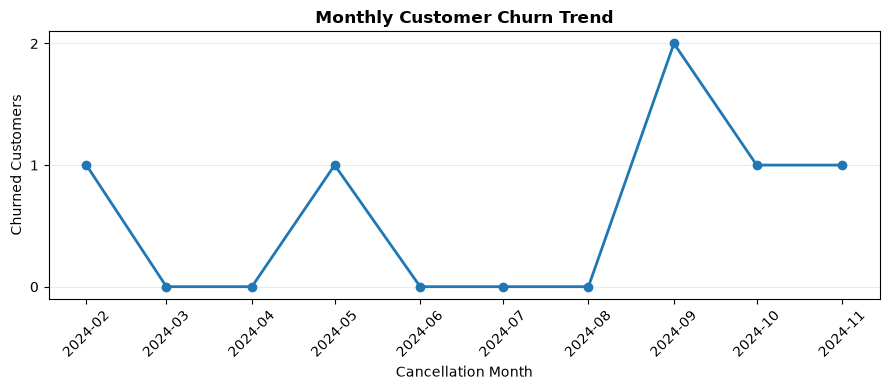

In [48]:
# Plotting and saving the monthly customer churn trend
plt.figure(figsize = (9, 4))

plt.plot(
    monthly_churn['cancellation_month'],
    monthly_churn['churned_customers'],
    marker = 'o',
    linewidth = 2
)

plt.title('Monthly Customer Churn Trend', fontweight = 'bold')
plt.xlabel('Cancellation Month')
plt.ylabel('Churned Customers')
plt.yticks(
    range(int(monthly_churn['churned_customers'].max()) + 1)
)
plt.xticks(rotation=45)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(
    f'{FIG_DIR}/monthly_churn_trend.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

**Key finding:** Customer cancellations were intermittent rather than consistent throughout the year. September recorded the highest monthly churn with two cancellations, while several months recorded none. Because only six customers churned, the pattern should be interpreted as descriptive rather than evidence of seasonality.

### 5.2 Churn Rate by Subscription Plan

This comparison evaluates how customer churn varies across subscription tiers. Using churn rate rather than raw customer counts allows each plan to be compared fairly despite differences in customer volume.

In [49]:
# Calculate the churn rate for each subscription plan
plan_churn_rate = (
    df_viz.groupby('plan_type', as_index = False)
    .agg(churn_rate = ('churn_flag', 'mean'))
    .sort_values('churn_rate', ascending = False)
    .reset_index(drop = True)
)

plan_churn_rate['churn_rate'] = (plan_churn_rate['churn_rate'] * 100).round(2)
plan_churn_rate

,plan_type,churn_rate
0,Basic,60.00
1,Standard,22.22
2,Premium,14.29


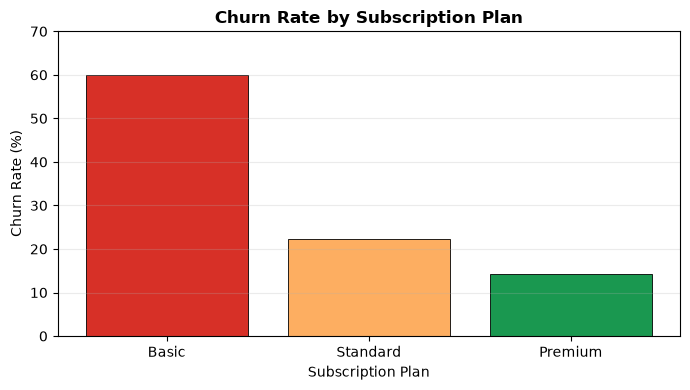

In [50]:
# Plot and save the churn rate by subscription plan
plt.figure(figsize=(7, 4))

plan_colors = {
    'Basic': '#D73027',
    'Standard': '#FDAE61',
    'Premium': '#1A9850'
}

plt.bar(
    plan_churn_rate['plan_type'],
    plan_churn_rate['churn_rate'],
    color = plan_churn_rate['plan_type'].map(plan_colors),
    edgecolor = 'black',
    linewidth = 0.6
)

plt.title('Churn Rate by Subscription Plan', fontweight = 'bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, plan_churn_rate['churn_rate'].max() + 10)
plt.grid(axis='y', alpha = 0.25)

plt.tight_layout()
plt.savefig(
    f'{FIG_DIR}/churn_rate_by_plan.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

**Key finding:** The Basic plan records the highest churn rate at 60.0%, compared with 22.2% for Standard and 14.3% for Premium. This suggests that retention efforts should prioritize Basic-plan customers, where attrition is substantially more concentrated.

### 5.3 Churn Rate by State

This comparison identifies geographic areas with elevated customer churn. Because several states contain only a small number of customers, these results should be treated as directional rather than conclusive.

In [51]:
# Calculating churn rate and customer volume by state
state_churn_rate = (
    df_viz.groupby('state', as_index = False)
    .agg(
        churn_rate = ('churn_flag', 'mean'),
        customer_count = ('customerid', 'nunique')
    )
    .sort_values('churn_rate')
    .reset_index(drop = True)
)

state_churn_rate['churn_rate'] = (state_churn_rate['churn_rate'] * 100).round(2)
state_churn_rate

,state,churn_rate,customer_count
0,Kathmandu,0.00,2
1,Maharashtra,0.00,3
2,Nagaland,0.00,1
3,Rajasthan,0.00,2
4,Uttar Pradesh,0.00,2
5,Delhi,25.00,4
6,Telangana,50.00,2
7,Meghalaya,66.67,3
8,Karnataka,100.00,2


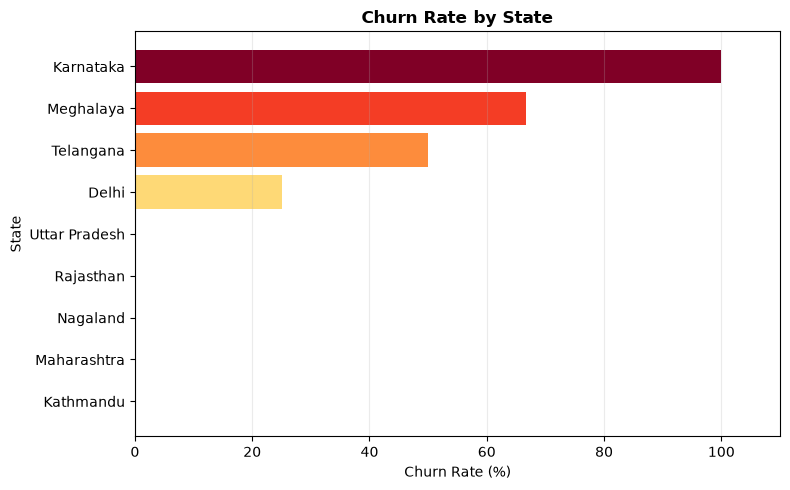

In [52]:
# Plotting and saving the churn rate by state
plt.figure(figsize = (8, 5))

color_scale = plt.Normalize(0, 100)
state_colors = plt.cm.YlOrRd(
    color_scale(state_churn_rate['churn_rate'])
)

plt.barh(
    state_churn_rate['state'],
    state_churn_rate['churn_rate'],
    color=state_colors
)

plt.title('Churn Rate by State', fontweight = 'bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('State')
plt.xlim(0, 110)
plt.grid(axis = 'x', alpha = 0.25)

plt.tight_layout()
plt.savefig(
    f'{FIG_DIR}/churn_rate_by_state.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

**Key finding:** Karnataka records the highest observed churn rate at 100%, followed by Meghalaya at 66.7% and Telangana at 50.0%. However, these states contain only two or three customers each, so the results should guide further investigation rather than support broad geographic conclusions.

### 5.4 Correlation Heatmap

This heatmap examines linear relationships among selected customer, subscription, and support metrics associated with churn. Identifier fields and directly derived features are excluded to prevent misleading or redundant correlations.

In [53]:
# Reviewing available features before building the correlation matrix
df_viz.columns.tolist()

['customerid',
 'subscription_start_date',
 'subscription_type',
 'renewal_date',
 'plan_type',
 'contract_type',
 'cancellation_date',
 'cancellation_reason',
 'monthly_charges',
 'cltv',
 'churn_score',
 'churn_flag',
 'customer_name',
 'country',
 'state',
 'gender',
 'dob',
 'complaint_date',
 'escalations',
 'csat_score',
 'complaint_count',
 'escalation_flag',
 'churn_risk']

In [54]:
# Calculate correlations among selected churn-related metrics
correlation_data = df_viz[
    [
        'monthly_charges',
        'cltv',
        'churn_score',
        'churn_flag',
        'csat_score',
        'complaint_count',
        'escalation_flag'
    ]
]

correlation_matrix = correlation_data.corr().round(2)
correlation_matrix

,monthly_charges,cltv,churn_score,churn_flag,csat_score,complaint_count,escalation_flag
monthly_charges,1.00,0.64,-0.40,-0.24,0.73,0.34,-0.19
cltv,0.64,1.00,-0.70,-0.47,-0.18,0.35,-0.28
churn_score,-0.40,-0.70,1.00,0.86,-0.47,0.49,0.63
churn_flag,-0.24,-0.47,0.86,1.00,-0.63,0.26,0.77
csat_score,0.73,-0.18,-0.47,-0.63,1.00,0.16,-0.78
complaint_count,0.34,0.35,0.49,0.26,0.16,1.00,-0.09
escalation_flag,-0.19,-0.28,0.63,0.77,-0.78,-0.09,1.00


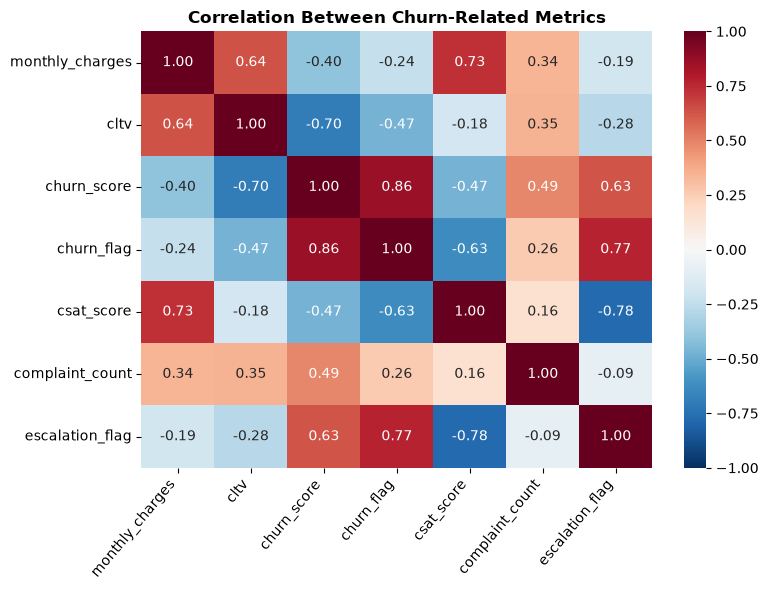

In [55]:
# Plotting and saving the correlation heatmap
plt.figure(figsize = (8, 6))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'RdBu_r',
    center = 0,
    vmin = -1,
    vmax = 1
)

plt.xticks(rotation = 50, ha = 'right')
plt.title(
    'Correlation Between Churn-Related Metrics',
    fontweight = 'bold'
)

plt.tight_layout()
plt.savefig(
    f'{FIG_DIR}/correlation_heatmap.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

**Key finding:** Actual churn is most strongly associated with churn score (0.86) and escalation status (0.77). The escalation relationship is the actionable one — customers whose support issues require escalation are candidates for early retention intervention. The churn-score relationship should be read with caution: that field is a provided model output that separates the outcome perfectly, so its correlation reflects how the dataset was constructed rather than an independently validated signal. Correlation indicates association, not causation.

### 5.5 Churn Rate by Contract Type

This comparison evaluates whether customer churn differs between monthly and annual contracts. Churn rate is used instead of raw churn counts so the contract groups can be compared fairly despite differences in customer volume.

In [56]:
# Calculating churn rate and customer volume by contract type
contract_churn_rate = (
    df_viz.groupby('contract_type', as_index=False)
    .agg(
        churn_rate = ('churn_flag', 'mean'),
        customer_count = ('customerid', 'nunique')
    )
    .sort_values('churn_rate', ascending = False)
    .reset_index(drop = True)
)

contract_churn_rate['churn_rate'] = (
    contract_churn_rate['churn_rate'] * 100
).round(2)

contract_churn_rate

,contract_type,churn_rate,customer_count
0,Monthly,55.56,9
1,Annual,8.33,12


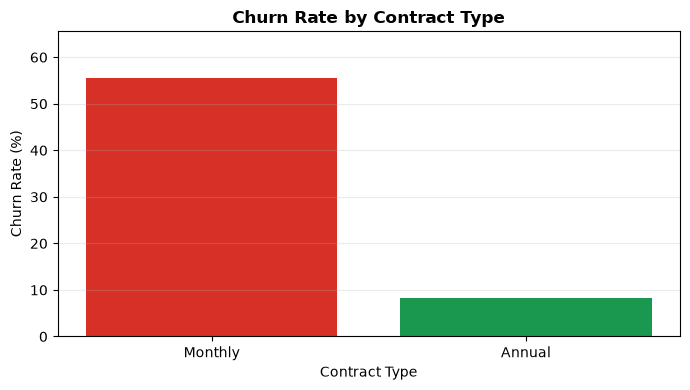

In [57]:
# Plotting and saving the churn rate by contract type
plt.figure(figsize = (7, 4))

contract_colors = {
    'Monthly': '#D73027',
    'Annual': '#1A9850'
}

plt.bar(
    contract_churn_rate['contract_type'],
    contract_churn_rate['churn_rate'],
    color=contract_churn_rate['contract_type'].map(contract_colors)
)

plt.title('Churn Rate by Contract Type', fontweight = 'bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, contract_churn_rate['churn_rate'].max() + 10)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(
    f'{FIG_DIR}/churn_rate_by_contract.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

**Key finding:** Monthly-contract customers record a 55.6% churn rate, compared with only 8.3% among annual-contract customers. This makes contract type one of the clearest retention indicators and suggests that encouraging monthly customers to adopt annual plans could reduce attrition.

## 6. Pivot Table Analysis

Pivot tables provide a compact way to compare churn across customer segments. Rather than repeat the single-dimension breakdowns already covered above, this section combines churn, customer volume, and revenue into one subscription-plan summary.

### 6.1 Subscription Plan Performance Summary

This pivot table combines churn rate, customer volume, and monthly revenue to compare overall subscription-plan performance.

In [58]:
# Summarizing key performance metrics by subscription plan
plan_performance_pivot = pd.pivot_table(
    data = df_viz,
    index = 'plan_type',
    values = [
        'churn_flag',
        'customerid',
        'monthly_charges'
    ],
    aggfunc = {
        'churn_flag': 'mean',
        'customerid': 'nunique',
        'monthly_charges': 'sum'
    }
).reset_index()

plan_performance_pivot['churn_flag'] = (plan_performance_pivot['churn_flag'] * 100).round(2)

plan_performance_pivot = plan_performance_pivot.rename(
    columns = {
        'churn_flag': 'churn_rate',
        'customerid': 'customer_count',
        'monthly_charges': 'total_monthly_charges'
    }
)
plan_performance_pivot

,plan_type,churn_rate,customer_count,total_monthly_charges
0,Basic,60.00,5,52.95
1,Premium,14.29,7,218.93
2,Standard,22.22,9,123.91


**Key finding:** The Basic plan has the highest churn rate at 60.0% despite having the fewest customers, making it the most urgent retention concern. Standard has the largest customer base with a substantially lower churn rate of 22.2%, while Premium performs best with the lowest churn rate at 14.3%. 

## 7. Business Insights and Recommendations

The analysis highlights several customer segments and behavioral signals associated with elevated churn. The following findings translate the results into practical retention priorities.

### 7.1 Key Business Insights

1. **Contract type is a major retention indicator.** Monthly-contract customers have a churn rate of 55.6%, compared with only 8.3% for annual-contract customers.

2. **Basic-plan customers are the highest-risk subscription segment.** The Basic plan records a 60.0% churn rate, substantially higher than Standard at 22.2% and Premium at 14.3%.

3. **Support escalations are strongly associated with churn.** Escalation status has a correlation of 0.77 with actual churn, indicating that unresolved or severe support issues may serve as an important warning signal.

4. **Geographic churn results require caution.** Karnataka, Meghalaya, and Telangana show elevated churn rates, but each state contains only a small number of customers, so these patterns should be treated as directional.

5. **The observed monthly churn pattern is intermittent.** September recorded the highest number of cancellations, but the small number of churn events is insufficient to establish seasonality.

### 7.2 Recommended Actions

1. **Prioritize monthly-contract customers for retention campaigns.** Offer targeted incentives, loyalty benefits, or discounted annual upgrades before their next renewal date.

2. **Investigate the Basic-plan customer experience.** Review pricing, included features, onboarding, and service quality to understand why Basic customers churn at a much higher rate.

3. **Use support escalations as an early-warning signal.** Flag customers with escalated complaints for proactive follow-up and faster issue resolution.

4. **Focus retention resources on high-risk customers.** Combine churn score, escalation status, plan type, and contract type to identify customers who may require immediate intervention.

5. **Collect more complete customer feedback.** CSAT coverage is too limited for reliable comparison, so satisfaction surveys should be captured consistently across both retained and churned customers.

6. **Avoid overreacting to small geographic segments.** Gather more customer data before making state-specific retention or marketing decisions.